모델 훈련 (epochs=2):
Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7462 - loss: 0.9864 - val_accuracy: 0.9050 - val_loss: 0.3497
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9050 - loss: 0.3439 - val_accuracy: 0.9215 - val_loss: 0.2864

모델 훈련 (epochs=5):
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7454 - loss: 1.0282 - val_accuracy: 0.9041 - val_loss: 0.3567
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9022 - loss: 0.3522 - val_accuracy: 0.9204 - val_loss: 0.2898
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9158 - loss: 0.3017 - val_accuracy: 0.9280 - val_loss: 0.2578
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9280 - loss: 0.2602 - val_accuracy: 0.9348 - val_loss: 0.2336
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9332 - loss: 0.2355 - val_accuracy: 0.9386 - val_loss: 0.2160

정확도 비교
epochs=2 - 훈련 정확도: 0.9083
epochs=2 - 테스트 정확도: 0.9215

/tmp/ipython-input-609891332.py:71: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-609891332.py:71: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-609891332.py:71: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-609891332.py:71: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-609891332.py:71: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-609891332.py:71: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-609891332.py:71: UserWarning: Glyph 47144 (\N{HANGUL SYLLABLE RYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


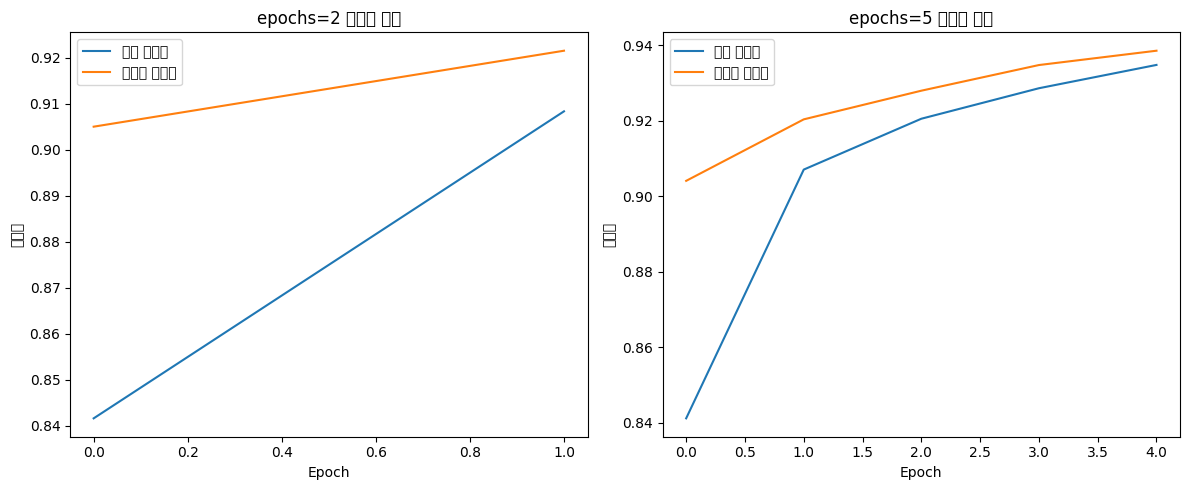


정확도 차이 분석
epochs=2와 epochs=5 정확도 차이의 원인:
1. 더 많은 훈련 에포크 (epochs=5):
   - 모델이 데이터 패턴을 학습할 기회가 더 많음
   - 가중치 업데이트 횟수가 더 많아 매개변수 조정이 더 정밀함
   - 지역 최적해로 더 잘 수렴할 수 있음
2. 학습 곡선:
   - epochs=2: 모델이 데이터 특성을 완전히 학습하지 못했을 수 있음
   - epochs=5: 모델이 손실을 줄이고 정확도를 높일 시간이 더 많음
3. 경사 하강법:
   - SGD 옵티마이저 사용, 각 에포크마다 미니배치 데이터 기반으로 가중치 업데이트
   - 더 많은 에포크는 더 많은 가중치 업데이트 기회를 의미함
4. 잠재적 위험:
   - 에포크가 너무 많으면 과적합이 발생할 수 있음
   - 현재 차이는 epochs=5가 일반화 능력을 여전히 향상시키고 있음을 보여줌


In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# MNIST 데이터셋 로드
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# 데이터 전처리
train_images = train_images / 255.0
test_images = test_images / 255.0

# 모델 생성 - 은닉층 노드 수: 128
def create_model():
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=(28, 28)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    # SGD 옵티마이저와 정확도 메트릭을 사용하여 모델 컴파일
    model.compile(optimizer='sgd',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])  # 성능 측정을 위해 정확도 사용
    return model

# 모델 훈련 및 기록
print("모델 훈련 (epochs=2):")
model_2_epochs = create_model()
history_2 = model_2_epochs.fit(train_images, train_labels,
                              epochs=2,
                              validation_data=(test_images, test_labels),
                              verbose=1)

print("\n모델 훈련 (epochs=5):")
model_5_epochs = create_model()
history_5 = model_5_epochs.fit(train_images, train_labels,
                              epochs=5,
                              validation_data=(test_images, test_labels),
                              verbose=1)

# 최종 정확도 비교 표시
print("\n" + "="*60)
print("정확도 비교")
print("="*60)
print(f"epochs=2 - 훈련 정확도: {history_2.history['accuracy'][-1]:.4f}")
print(f"epochs=2 - 테스트 정확도: {history_2.history['val_accuracy'][-1]:.4f}")
print(f"epochs=5 - 훈련 정확도: {history_5.history['accuracy'][-1]:.4f}")
print(f"epochs=5 - 테스트 정확도: {history_5.history['val_accuracy'][-1]:.4f}")

# 정확도 변화 그래프 그리기
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'], label='훈련 정확도')
plt.plot(history_2.history['val_accuracy'], label='테스트 정확도')
plt.title('epochs=2 정확도 변화')
plt.xlabel('Epoch')
plt.ylabel('정확도')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_5.history['accuracy'], label='훈련 정확도')
plt.plot(history_5.history['val_accuracy'], label='테스트 정확도')
plt.title('epochs=5 정확도 변화')
plt.xlabel('Epoch')
plt.ylabel('정확도')
plt.legend()

plt.tight_layout()
plt.show()

# 차이 원인 설명
print("\n" + "="*60)
print("정확도 차이 분석")
print("="*60)
print("epochs=2와 epochs=5 정확도 차이의 원인:")
print("1. 더 많은 훈련 에포크 (epochs=5):")
print("   - 모델이 데이터 패턴을 학습할 기회가 더 많음")
print("   - 가중치 업데이트 횟수가 더 많아 매개변수 조정이 더 정밀함")
print("   - 지역 최적해로 더 잘 수렴할 수 있음")
print("2. 학습 곡선:")
print("   - epochs=2: 모델이 데이터 특성을 완전히 학습하지 못했을 수 있음")
print("   - epochs=5: 모델이 손실을 줄이고 정확도를 높일 시간이 더 많음")
print("3. 경사 하강법:")
print("   - SGD 옵티마이저 사용, 각 에포크마다 미니배치 데이터 기반으로 가중치 업데이트")
print("   - 더 많은 에포크는 더 많은 가중치 업데이트 기회를 의미함")
print("4. 잠재적 위험:")
print("   - 에포크가 너무 많으면 과적합이 발생할 수 있음")
print("   - 현재 차이는 epochs=5가 일반화 능력을 여전히 향상시키고 있음을 보여줌")